# Group project-Simulate wake field
Core Ideas: 

Simulating Wake pattern in low speed (low froude number) regime 

Regime change at higher speed (high froude number) 

Modelling the transition 

In this notebook, we are going to simulate the low speed case. First initialise.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

Assume that the fluid is incompressible and inviscid, the flow is irrotational, and we ignore surface tension. The Froude number is a dimensionless parameter that compares the inertial forces to gravitational forces in fluid flow. It is defined to be:

$F=\frac{U}{\sqrt{gL}}$,

where $U$ and $L$ are characteristic speed and length, $g$ is gravity constant.

In [ ]:
g = 9.81 # gravity (m/s^2)
speed = 1.0 # U (m/s)
length = 1.0 # L (m)
Froude_number = speed/np.sqrt(g*length)

The standard dispersion relation is:

$\omega^2=gk$.

Since a velocity potential of our assumption follows the laplace equation, we can write the ansatz solution of it:

$\bf{\Phi}=e^{i\omega t-ik(x\cos\theta+y\sin\theta)}e^{kz}$

Through calculation, can get $\omega=Uk\cos(\theta)$. (Equation came from https://www.wikiwaves.org/index.php/Ship_Kelvin_Wake)

Can solve that wavenumber $k=\frac{g}{U^2 {\cos\theta}^2}$.

Then we can use numerical method to input various theta value to get values of wavenumber under dispersion.

In [21]:
x = np.linspace(-10, 2, 700)   # downstream wake mainly behind source
y = np.linspace(-6, 6, 700)
X, Y = np.meshgrid(x, y)

In [ ]:
theta = np.linspace(-np.pi/2 + 0.02, np.pi/2 - 0.02, 2000)
dtheta = theta[1] - theta[0]
# Allowed wavenumber from deep-water dispersion
k = g / (speed**2 * np.cos(theta)**2)

(https://www.sciencedirect.com/science/article/pii/S0997754614001137)
This paper has assumed a Gaussian distribution of pressure at free surface. 

$p(x,y)=p_0 \mathrm{exp} (-\frac{{(x-Ut)}^2+y^2}{2L})$

Since the fourier transform of a gaussian is still a fourier transform, we can easily derive the fourier transform of the pressure to be:

$A\propto \mathrm{exp} (\frac{-L^2}{2} (k_x^2+k_y^2)) $.

Since the pressure is proportional to the amplitude, $A$ can be taken as the amplitude of the modes of the waves.

The waves can be defined to be:

$\eta = \int {A\cos \left( {{k_x}x + {k_y}y - \omega t} \right)d{k_x}d{k_y}}$.

For certain time, we can hard code using summation:

$\eta = \sum {A\cos (k(x\cos \theta  + y\sin \theta ))}$

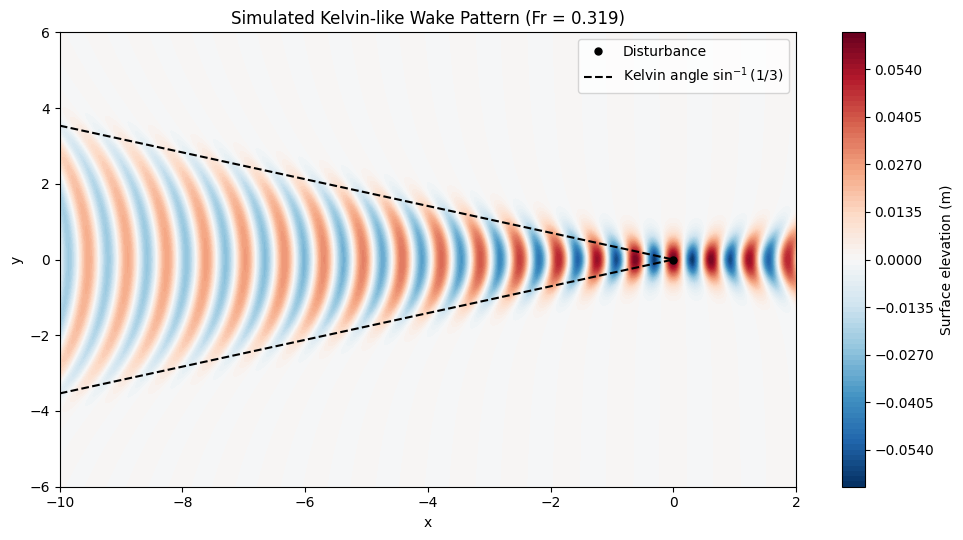

In [ ]:
const = 40
A = np.exp(-(k * length)**2 / const)

eta = np.zeros_like(X)

for i in tqdm(range(len(theta))):
    phase = k[i] * (X * np.cos(theta[i]) + Y * np.sin(theta[i]))
    eta += A[i] * np.cos(phase)

eta *= dtheta

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 5.5))
plt.contourf(X, Y, eta, levels=120, cmap="RdBu_r")
plt.colorbar(label="Surface elevation (m)")
# Disturbance at origin
plt.plot(0, 0, 'ko', markersize=5, label="Disturbance")
# Kelvin wedge lines: angle = arcsin(1/3)
kelvin_angle = np.arcsin(1/3)
x_line = np.linspace(-10, 0, 200)
y_upper = np.tan(kelvin_angle) * (-x_line)
y_lower = -np.tan(kelvin_angle) * (-x_line)

plt.plot(x_line, y_upper, 'k--', lw=1.5, label=r'Kelvin angle $\sin^{-1}(1/3)$')
plt.plot(x_line, y_lower, 'k--', lw=1.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Simulated Kelvin-like Wake Pattern (Fr = {Froude_number:.3f})")
plt.legend()
plt.tight_layout()
plt.show()